## **Proyecto de Machine Learning** | Predicción de abadono de cliente

Proyecto de Machine Learning, en el cual se utiliza un dataset extraído de Kaggle, sobre una compañia de IPS que ofrece servicio de Internet a los clientes. Este proyecto nos ayudará a saber que según las variables dependientes del mismo, predecir si un cliente abandonará el servicio ofrecido por la compañia. En el proyecto se realiza EDA, Ingeniería de Características, creación de modelos y su respectiva evaluación, etc.

**Este un proyecto que realizo de práctica, con datos sintéticos... con el fi de reforzar, aplicar mis conocimientos y destrezas en el campo.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE



In [3]:
# Modulo para ocultar las advertencias

import warnings
warnings.filterwarnings('ignore')


# 1- Carga de datos

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Customer Churn Prediction/customer_churn_data.csv')

# 2- Análisis exploratorio de Datos

In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [6]:
# Campo, tipo de dato y nulos.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [7]:
# Nulos

nulos = df.isna().sum()
nulos[nulos>0]

,0
InternetService,297


In [8]:
df.InternetService.unique()

array(['Fiber Optic', 'DSL', nan], dtype=object)

Dejaremos el campo vacío en los registros del campo 'InternetService', que sean 'nan'. Son de clientes que no tienen el servicio de internet contratado.

In [9]:
# Imputaremos los registros nulos del campo InternetService un campo vacío.

df.InternetService = df['InternetService'].fillna('')

# Validamos los nulos otra vez

nulos = df.isna().sum()
nulos[nulos>0]

,0


In [10]:
# Verificando si tenemos duplicados

df.duplicated().sum()

np.int64(0)

In [11]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes


In [12]:
# Estadísticas generales.

df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


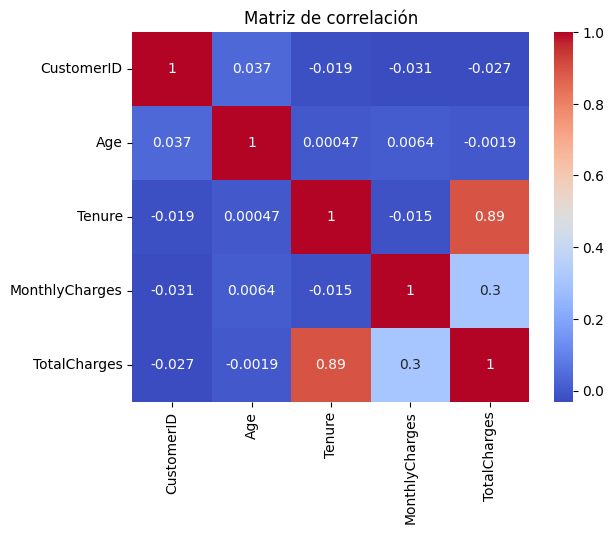

In [13]:
# Variable de columnas númericas y su correlacion

cols_numericas = df.select_dtypes(include=["number"])

sns.heatmap(cols_numericas.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

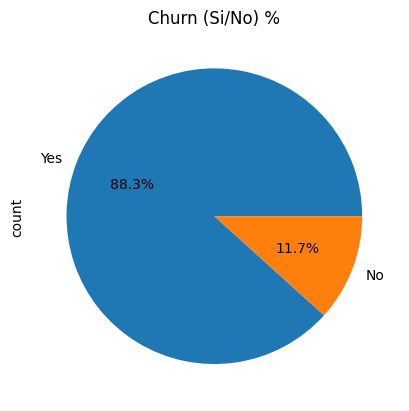

In [14]:
# Verficiamos los porcentajes (Si/No) de Churn

df['Churn'].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title('Churn (Si/No) %')
plt.show()

In [15]:
df.head(3)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes


In [16]:
df.groupby('Churn')['Churn'].count()

,Churn
Churn,
No,117
Yes,883


In [17]:
# Churn agrupado por la media de cargos mensuales

df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,62.54641
Yes,75.96077


In [18]:
# Churn, Genero X cargos mensuales

df.groupby(['Churn','Gender'])['MonthlyCharges'].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [19]:
# Churn por tenencia

df.groupby('Churn')['Tenure'].mean()

,Tenure
Churn,
No,30.264957
Yes,17.476784


In [20]:
# Churn por edad

df.groupby('Churn')['Age'].mean()

,Age
Churn,
No,43.487179
Yes,44.831257


In [21]:
# Churn por cargos totales

df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
No,1842.510256
Yes,1346.308448


Podemos visualizar que el tipo de contrato que más genera es el de 'Mes a mes', era de esperarse ya que los clientes normalmente optan por este tipo de contratos rápidos y no del costo contundente en el momento, como son los demás planes de servicio.

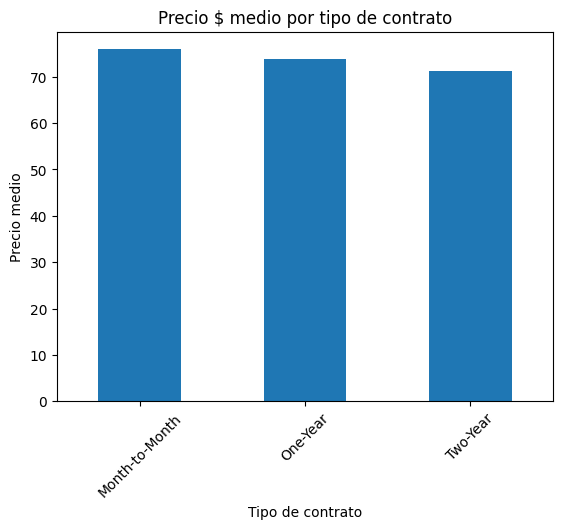

In [22]:
# Tipo de contrato por cargos mensuales

df.groupby('ContractType')['MonthlyCharges'].mean().plot(kind='bar')
plt.title('Precio $ medio por tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Precio medio')
plt.xticks(rotation=45)
plt.show()

Se visualiza que, muchos clientes abandonan un poco rápido el servicio, esto lo podemos visualizar con claridad en el histograma de la tenencia, esa cola larga a la derecha indica que, hay poquísimos clientes que apenas duran 2 años (solo un 27% de los clientes, duran 2 o más años con el servicio) contratando el servicio. Es decir, el servicio ofrecido da a demostrar que no retiene a los clientes por mucho tiempo.

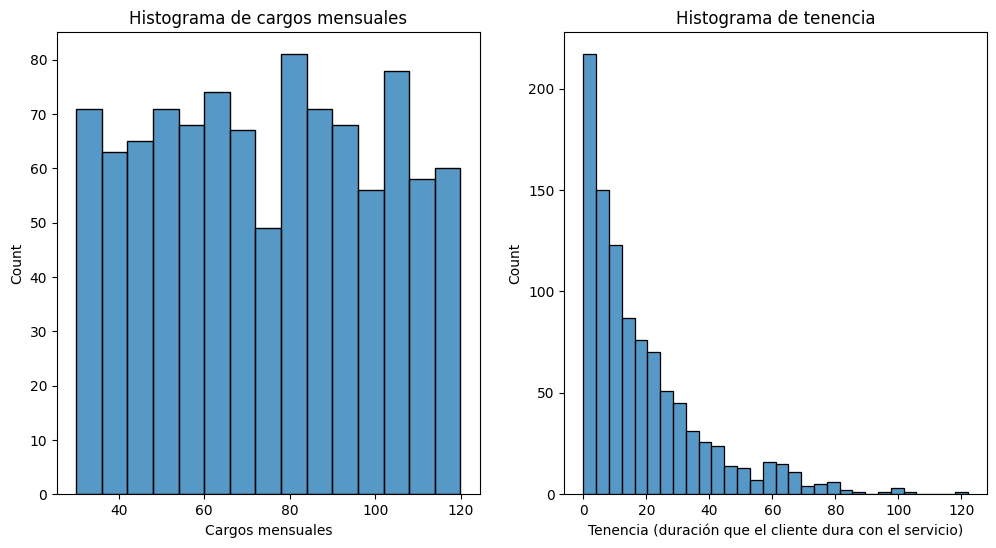


Cantidad de clientes que han durado 2 o más años de servicio: 277 (apróximadamente el 27% de los clientes totales)


In [23]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

sns.histplot(df['MonthlyCharges'], bins=15, ax=axes[0])
axes[0].set_title('Histograma de cargos mensuales')
axes[0].set_xlabel('Cargos mensuales')

sns.histplot(df['Tenure'], ax=axes[1])
axes[1].set_title('Histograma de tenencia')
axes[1].set_xlabel('Tenencia (duración que el cliente dura con el servicio)')
plt.show()

print()
print(f'Cantidad de clientes que han durado 2 o más años de servicio: {df[df['Tenure'] > 24].value_counts().sum()} (apróximadamente el 27% de los clientes totales)')


In [24]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,,2208.32,No,Yes
